# Fees and net returns

Every trade and every position costs something, and a portfolio that looks good *gross* can be
mediocre *net*. `PortfolioOptimisers.jl` models costs with `Fees` — proportional and
fixed charges on long and short positions, plus a turnover-based component — and lets you both
**optimise net of fees** (the optimiser trades expected return against cost) and **evaluate** a
portfolio's net return after the fact with `calc_net_returns`.

This closes the constraints-and-costs group: where [Turnover and Tracking](05_Turnover_and_Tracking.md)
charged for *moving*, this page charges for *holding*.

> **When to reach for this**
>
> Reach for fees whenever costs are material to the decision, not just the reporting: high-fee
> instruments, asymmetric long/short costs, or a strategy whose gross edge is thin enough that
> fees decide whether it is worth running. Use the per-asset or per-group form to make the
> optimiser *prefer cheap exposure*, and `calc_net_returns` to check that a candidate book still
> earns its keep after costs.

In [1]:
using PortfolioOptimisers, CSV, TimeSeries, DataFrames, PrettyTables, Clarabel, StatsPlots,
      GraphRecipes

resfmt = (v, i, j) -> begin
    return if j == 1
        v
    else
        isa(v, AbstractFloat) ? "$(round(v*100, digits=3)) %" : v
    end
end;

## 1. ReturnsResult data

In [2]:
X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X)
pr = prior(EmpiricalPrior(), rd)
N = length(rd.nx)

slv = Solver(; name = :clarabel, solver = Clarabel.Optimizer,
             settings = Dict("verbose" => false),
             check_sol = (; allow_local = true, allow_almost = true))
rf = 4.2 / 100 / 252

res_base = optimise(MeanRisk(; obj = MaximumRatio(; rf = rf),
                             opt = JuMPOptimiser(; pe = pr, slv = slv)))

MeanRiskResult
  jr ┼ JuMPOptimisationResult
     │        pa ┼ ProcessedJuMPOptimiserAttributes
     │           │        pr ┼ LowOrderPrior
     │           │           │         X ┼ 252×20 Matrix{Float64}
     │           │           │        mu ┼ 20-element Vector{Float64}
     │           │           │     sigma ┼ 20×20 Matrix{Float64}
     │           │           │      chol ┼ nothing
     │           │           │         w ┼ nothing
     │           │           │       ens ┼ nothing
     │           │           │       kld ┼ nothing
     │           │           │        ow ┼ nothing
     │           │           │        rr ┼ nothing
     │           │           │      f_mu ┼ nothing
     │           │           │   f_sigma ┼ nothing
     │           │           │       f_w ┴ nothing
     │           │        wb ┼ WeightBounds
     │           │           │   lb ┼ 20-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}
     │          

## 2. Fees erase returns

The starkest way to see why fees matter: take the unconstrained maximum-ratio book and look at
its gross return against its return *net* of a proportional fee. `calc_fees` computes the
cost of holding a weight vector, and `calc_net_returns` deducts it from the gross
returns. A flat 0.2% long fee on this book costs about as much per day as the strategy earns —
the net edge nearly vanishes.

In [3]:
fee = Fees(; l = 0.002)
gross_daily = sum(rd.X * res_base.w) / size(rd.X, 1)
net_daily = sum(calc_net_returns(res_base.w, rd.X, fee)) / size(rd.X, 1)
fee_cost = calc_fees(res_base.w, fee)

pretty_table(DataFrame("Quantity" => ["Gross daily return", "Fee cost", "Net daily return"],
                       "Value" => [gross_daily, fee_cost, net_daily]);
             formatters = [resfmt],
             title = "A 0.2% long fee against this book's daily edge")

A 0.2% long fee against this book's daily edge
┌────────────────────┬─────────┐
│           Quantity │   Value │
│             String │ Float64 │
├────────────────────┼─────────┤
│ Gross daily return │   0.2 % │
│           Fee cost │   0.2 % │
│   Net daily return │  -0.0 % │
└────────────────────┴─────────┘


## 3. Optimising net of fees

Passing `fees` to the `JuMPOptimiser` makes the optimiser maximise the ratio *after*
costs, so it only takes exposure whose return justifies its fee. A uniform `Fees` charges
the same rate everywhere (`l` for long, `s` for short positions).

In [4]:
res_fee = optimise(MeanRisk(; obj = MaximumRatio(; rf = rf),
                            opt = JuMPOptimiser(; pe = pr, slv = slv,
                                                fees = Fees(; l = 0.002))))

MeanRiskResult
  jr ┼ JuMPOptimisationResult
     │        pa ┼ ProcessedJuMPOptimiserAttributes
     │           │        pr ┼ LowOrderPrior
     │           │           │         X ┼ 252×20 Matrix{Float64}
     │           │           │        mu ┼ 20-element Vector{Float64}
     │           │           │     sigma ┼ 20×20 Matrix{Float64}
     │           │           │      chol ┼ nothing
     │           │           │         w ┼ nothing
     │           │           │       ens ┼ nothing
     │           │           │       kld ┼ nothing
     │           │           │        ow ┼ nothing
     │           │           │        rr ┼ nothing
     │           │           │      f_mu ┼ nothing
     │           │           │   f_sigma ┼ nothing
     │           │           │       f_w ┴ nothing
     │           │        wb ┼ WeightBounds
     │           │           │   lb ┼ 20-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}
     │          

## 4. Differential fees steer the allocation

Costs are rarely uniform — some instruments are expensive to hold. A `FeesEstimator`
(the estimator counterpart of `Fees`) accepts per-asset or per-group rates over an
`AssetSets`, exactly like the linear constraints. Charging a punitive fee on the sector
the baseline loved makes the optimiser walk away from it.

In [5]:
sets = AssetSets(;
                 dict = Dict("nx" => rd.nx,
                             "healthcare" => ["JNJ", "LLY", "MRK", "PFE", "UNH"]))
res_diff = optimise(MeanRisk(; obj = MaximumRatio(; rf = rf),
                             opt = JuMPOptimiser(; pe = pr, slv = slv, sets = sets,
                                                 fees = FeesEstimator(;
                                                                      l = ["healthcare" =>
                                                                               0.02]))))

function healthcare_weight(w)
    return sum(w[i] for i in eachindex(w) if rd.nx[i] in sets.dict["healthcare"])
end
pretty_table(DataFrame("Portfolio" => ["Baseline", "Healthcare fee 2%"],
                       "Healthcare weight" =>
                           [healthcare_weight(res_base.w), healthcare_weight(res_diff.w)]);
             formatters = [resfmt],
             title = "A targeted fee steers exposure away from a sector")

A targeted fee steers exposure away from a sector
┌───────────────────┬───────────────────┐
│         Portfolio │ Healthcare weight │
│            String │           Float64 │
├───────────────────┼───────────────────┤
│          Baseline │          65.979 % │
│ Healthcare fee 2% │             0.0 % │
└───────────────────┴───────────────────┘


## 5. Fixed fees need a MIP solver

Proportional fees (`l`, `s`) are convex and solve with Clarabel. **Fixed** fees (`fl`, `fs`) — a
flat charge incurred only *if* a position is opened — are semi-continuous (zero or the fee), the
same structure as thresholds and cardinality. They require a mixed-integer-capable solver
([Pajarito](https://github.com/jump-dev/Pajarito.jl) + [HiGHS](https://github.com/jump-dev/HiGHS.jl));
handed to a continuous-only solver the problem fails to solve rather than returning a wrong
answer. See [Budget Constraints](01_Budget_Constraints.md) for the MIP setup. Fees also carry a
turnover component (the `tn` field), tying the holding cost here to the trading cost in
[Turnover and Tracking](05_Turnover_and_Tracking.md).

## 6. Comparing the books

Gross-optimal, net-optimal, and fee-steered — same prior and objective, different cost
assumptions.

         Weights under each fee assumption
┌────────┬──────────┬────────────┬────────────────┐
│  Asset │    Gross │ Net (0.2%) │ Healthcare fee │
│ String │  Float64 │    Float64 │        Float64 │
├────────┼──────────┼────────────┼────────────────┤
│   AAPL │    0.0 % │      0.0 % │          0.0 % │
│    AMD │    0.0 % │      0.0 % │          0.0 % │
│    BAC │    0.0 % │      0.0 % │          0.0 % │
│    BBY │    0.0 % │      0.0 % │          0.0 % │
│    CVX │    0.0 % │      0.0 % │          0.0 % │
│     GE │    0.0 % │      0.0 % │          0.0 % │
│     HD │    0.0 % │      0.0 % │          0.0 % │
│    JNJ │    0.0 % │      0.0 % │          0.0 % │
│    JPM │    0.0 % │      0.0 % │          0.0 % │
│     KO │    0.0 % │      0.0 % │        9.919 % │
│    LLY │  0.002 % │      0.0 % │          0.0 % │
│    MRK │ 65.977 % │      0.0 % │          0.0 % │
│   MSFT │    0.0 % │      0.0 % │          0.0 % │
│    PEP │    0.0 % │      0.0 % │          0.0 % │
│      ⋮ │        ⋮ │

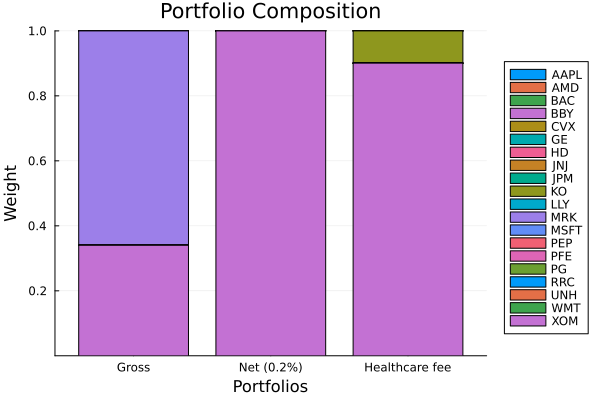

In [6]:
results = [res_base, res_fee, res_diff]
labels = ["Gross", "Net (0.2%)", "Healthcare fee"]

pretty_table(DataFrame(["Asset" => rd.nx,
                        [labels[i] => results[i].w for i in eachindex(results)]...]);
             formatters = [resfmt], title = "Weights under each fee assumption")

plot_stacked_bar_composition(results, rd; xticks = (1:length(labels), labels))

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*